棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [17]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\complex.csv"
df=pd.read_csv(csv_path)

In [18]:
def parse_chess_data(df):
    df['Stage Analysis'] = df['Stage Analysis'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    list_cols = ['Evaluation', 'Judgments', 'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S']
    
    for col in list_cols:
        df[col] = df[col].apply(lambda x: [float(i) for i in x.split(',')] if isinstance(x, str) and col != 'Judgments' else x)
        
    df['Judgments'] = df['Judgments'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    return df
df=parse_chess_data(df)
df.head()

,row_idx,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,Judgments,...,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,127214,Teodora Injac,Josefine Heinemann,47.571429,81.479751,27.171429,87.306038,{'beginning': {'white': {'accuracy': 97.074174...,"[0.2, 0.21, 0.19, 0.26, 0.26, 0.25, 0.23, 0.25...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,4,1,1,1,"[32.0, -20.0, 21.0, -19.0, 26.0, -26.0, 25.0, ...","[23.0, -21.0, 13.0, -27.0, 25.0, -28.0, 2.0, -...","[0.711, 0.525, 0.69, 0.69, 0.525, 0.55, 0.909,...","[0.492, 0.93, 0.535, 0.535, 0.93, 0.863, 0.138...",15.154733,10.788352
1,127215,Mauri Lehtosaari,Jose Garcia Molina,44.441176,84.751150,28.382353,91.294191,{'beginning': {'white': {'accuracy': 97.025433...,"[0.22, 0.28, 0.24, 0.25, 0.15, 0.13, 0.02, 0.1...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,3,0,2,2,"[27.0, -22.0, 28.0, -24.0, 25.0, -15.0, 13.0, ...","[25.0, -30.0, 27.0, -26.0, 17.0, -17.0, 10.0, ...","[0.55, 0.69, 0.525, 0.55, 0.69, 0.55, 0.574, 1...","[0.863, 0.535, 0.93, 0.863, 0.535, 0.863, 0.8,...",15.719362,11.608778
2,127216,Lazaro Lorenzo De La Riva,Luisa Bashylina,33.837838,86.467746,56.194444,82.286900,{'beginning': {'white': {'accuracy': 85.555278...,"[0.2, 0.64, 0.11, 0.33, 0.22, 0.24, 0.27, 0.41...","[-, -, -, -, -, -, -, -, -, Inaccuracy, Inaccu...",...,5,1,1,6,"[21.0, -20.0, 64.0, -11.0, 33.0, -22.0, 24.0, ...","[17.0, -23.0, 51.0, -33.0, 32.0, -25.0, 24.0, ...","[0.599, 0.574, 0.786, 0.9, 0.525, 0.574, 0.5, ...","[0.74, 0.8, 0.348, 0.152, 0.93, 0.8, 1.0, 0.93...",12.006086,14.033451
3,127217,Mukhiddin Madaminov,Aleksa Micic,22.057143,90.078757,40.735294,83.533783,{'beginning': {'white': {'accuracy': 94.158590...,"[0.23, 0.24, -0.06, 0.01, 0.03, 0.05, 0.04, 0....","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,2,0,4,"[22.0, -23.0, 24.0, 6.0, 1.0, -3.0, 5.0, -4.0,...","[21.0, -25.0, 23.0, -19.0, -12.0, -11.0, -6.0,...","[0.525, 0.55, 0.525, 0.924, 0.786, 0.69, 0.75,...","[0.93, 0.863, 0.93, 0.114, 0.348, 0.535, 0.415...",14.661026,13.735810
4,127218,Guillermo José Llanos,Ivan Zemlyanskii,53.638889,80.405599,29.694444,90.266949,{'beginning': {'white': {'accuracy': 98.224259...,"[0.21, 0.23, 0.1, 0.05, 0.03, 0.03, 0.0, 0.25,...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,4,1,1,2,"[26.0, -21.0, 23.0, -10.0, 5.0, -3.0, 3.0, 0.0...","[24.0, -22.0, 16.0, -10.0, 2.0, -14.0, 3.0, -8...","[0.55, 0.525, 0.668, 0.5, 0.574, 0.75, 0.5, 0....","[0.863, 0.93, 0.582, 1.0, 0.8, 0.415, 1.0, 0.5...",19.103834,16.445035


# Information Unit:   
# Complexity + Judgment + Player + GameID + Move_Index

In [19]:
def explode_chess_data(row):
    game_id = row['row_idx'] 
    white = row['White']
    black = row['Black']
    
    complexities = row['Complexity S'] 
    E1s=row['Complexity E1']
    E2s=row['Complexity E2']
    Ps=row['Complexity P']

    judgments = row['Judgments']
    if not isinstance(complexities, list):
        complexities = [] 
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(Ps, list):
        Ps = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = min(len(complexities), len(judgments))
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'Game_ID': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'S': complexities[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'P':Ps[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data

all_moves = []

for index, row in df.iterrows():
    moves = explode_chess_data(row)
    all_moves.extend(moves)


df_moves = pd.DataFrame(all_moves)
df_moves.head()

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,127214,1,Teodora Injac,White,0.492,32.0,23.0,0.711,-,0,0
1,127214,2,Josefine Heinemann,Black,0.930,-20.0,-21.0,0.525,-,0,0
2,127214,3,Teodora Injac,White,0.535,21.0,13.0,0.690,-,0,0
3,127214,4,Josefine Heinemann,Black,0.535,-19.0,-27.0,0.690,-,0,0
4,127214,5,Teodora Injac,White,0.930,26.0,25.0,0.525,-,0,0


distributions

In [ ]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
    #hist_df = pd.DataFrame({'bin_start': bin_edges[:-1],'bin_end': bin_edges[1:],'count': counts})

=== S>0 Distribution 每个区间步数 ===
0.001-0.021: 199410            | 0.021-0.041: 67246
0.041-0.061: 46558             | 0.061-0.081: 39658
0.081-0.101: 29595             | 0.101-0.121: 31638
0.121-0.141: 35075             | 0.141-0.161: 18600
0.161-0.181: 19458             | 0.181-0.201: 20776
0.201-0.221: 21824             | 0.221-0.241: 22820
0.241-0.261: 24318             | 0.261-0.281: 25838
0.281-0.301: 27432             | 0.301-0.321: 29427
0.321-0.341: 0                 | 0.341-0.361: 31342
0.361-0.381: 33657             | 0.381-0.401: 0
0.401-0.421: 36419             | 0.421-0.441: 0
0.441-0.461: 39637             | 0.461-0.481: 0
0.481-0.501: 42731             | 0.501-0.520: 0
0.520-0.540: 46811             | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 52107
0.600-0.620: 0                 | 0.620-0.640: 57539
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 63565             | 0.700-0.720: 0
0.720-0.740: 72798             | 0.740-0.760: 0
0.760-0.780:

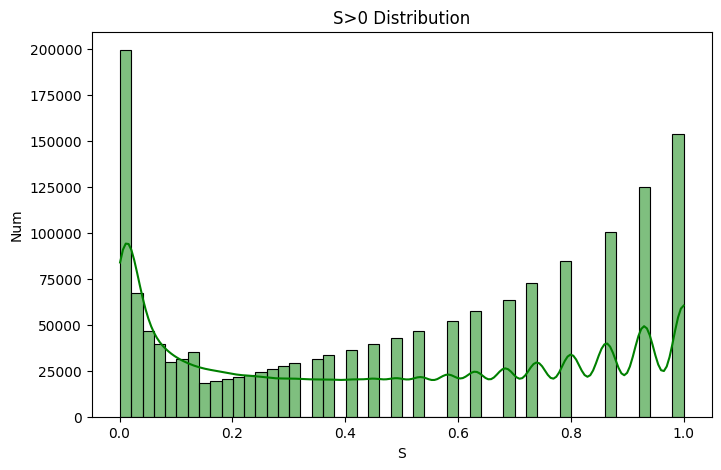

In [26]:
#complex distribution
#所有步数，除去S=0的，在不同S值区间的分布情况
df_nontrivial = df_moves[df_moves['S'] > 0]
hist_df_nontrivial = plot_hist_with_values(
    df_nontrivial,       # DataFrame
    col='S',             # 要绘制的列
    bins=50,             # 分50个区间
    kde=True,            # 显示 KDE 曲线
    color='green',       # 柱子颜色
    title='S>0 Distribution', 
    xlabel='S', 
    ylabel='Num'
)

=== S Distribution 每个区间步数 ===
0.000-0.020: 558801            | 0.020-0.040: 67246
0.040-0.060: 46558             | 0.060-0.080: 39658
0.080-0.100: 29595             | 0.100-0.120: 31638
0.120-0.140: 35075             | 0.140-0.160: 18600
0.160-0.180: 19458             | 0.180-0.200: 20776
0.200-0.220: 21824             | 0.220-0.240: 22820
0.240-0.260: 24318             | 0.260-0.280: 25838
0.280-0.300: 27432             | 0.300-0.320: 29427
0.320-0.340: 0                 | 0.340-0.360: 31342
0.360-0.380: 0                 | 0.380-0.400: 33657
0.400-0.420: 36419             | 0.420-0.440: 0
0.440-0.460: 39637             | 0.460-0.480: 0
0.480-0.500: 42731             | 0.500-0.520: 0
0.520-0.540: 46811             | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 52107
0.600-0.620: 0                 | 0.620-0.640: 57539
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 63565             | 0.700-0.720: 0
0.720-0.740: 0                 | 0.740-0.760: 72798
0.760-

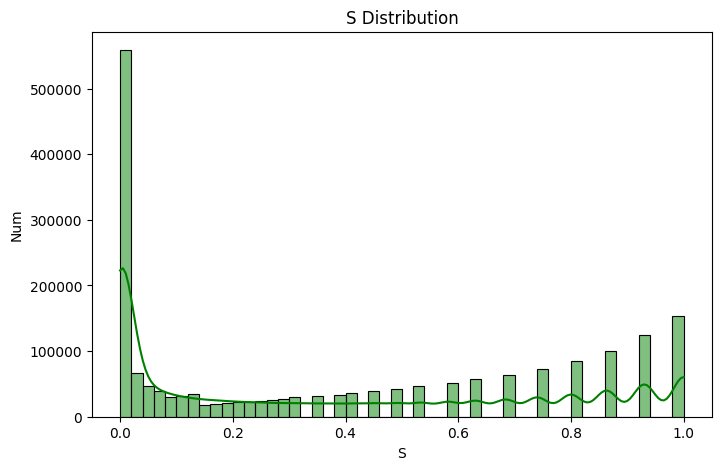

In [29]:
#所有步数，包含S=0，在不同S值区间的分布情况
plot_hist_with_values(df=df_moves, col='S', bins=50, kde=True, title='S Distribution', xlabel='S', ylabel='Num',color='green')

=== Mistake / Blunder 's S distribution 每个区间步数 ===
0.000-0.020: 72653             | 0.020-0.040: 4605
0.040-0.060: 2800              | 0.060-0.080: 2183
0.080-0.100: 1575              | 0.100-0.120: 1712
0.120-0.140: 1719              | 0.140-0.160: 887
0.160-0.180: 892               | 0.180-0.200: 951
0.200-0.220: 914               | 0.220-0.240: 976
0.240-0.260: 1067              | 0.260-0.280: 1061
0.280-0.300: 1042              | 0.300-0.320: 1096
0.320-0.340: 0                 | 0.340-0.360: 1127
0.360-0.380: 0                 | 0.380-0.400: 1194
0.400-0.420: 1232              | 0.420-0.440: 0
0.440-0.460: 1249              | 0.460-0.480: 0
0.480-0.500: 1352              | 0.500-0.520: 0
0.520-0.540: 1451              | 0.540-0.560: 0
0.560-0.580: 0                 | 0.580-0.600: 1582
0.600-0.620: 0                 | 0.620-0.640: 1549
0.640-0.660: 0                 | 0.660-0.680: 0
0.680-0.700: 1733              | 0.700-0.720: 0
0.720-0.740: 0                 | 0.740-0.760: 1945
0

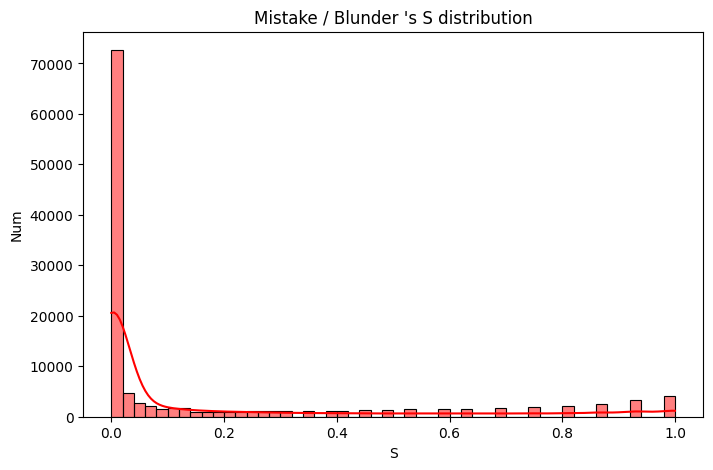

In [30]:
#mistake blunder distribution
# 只保留错误步
errors_df = df_moves[df_moves['Is_Error']==1]

plot_hist_with_values(df=errors_df, col='S', bins=50, kde=True, title="Mistake / Blunder 's S distribution", xlabel='S', ylabel='Num',color='red')


=== Error Probability across Complexity Levels ===
(-0.001, 0.02]: n=558801, err=0.1300                    | (0.02, 0.04]: n=67246, err=0.0685
(0.04, 0.06]: n=46558, err=0.0601                       | (0.06, 0.08]: n=39658, err=0.0550
(0.08, 0.1]: n=29595, err=0.0532                        | (0.1, 0.12]: n=31638, err=0.0541
(0.12, 0.14]: n=35075, err=0.0490                       | (0.14, 0.16]: n=18600, err=0.0477
(0.16, 0.18]: n=19458, err=0.0458                       | (0.18, 0.2]: n=20776, err=0.0458
(0.2, 0.22]: n=21824, err=0.0419                        | (0.22, 0.24]: n=22820, err=0.0428
(0.24, 0.26]: n=24318, err=0.0439                       | (0.26, 0.28]: n=25838, err=0.0411
(0.28, 0.3]: n=27432, err=0.0380                        | (0.3, 0.32]: n=29427, err=0.0372
(0.32, 0.34]: n=0, err=nan                              | (0.34, 0.36]: n=31342, err=0.0360
(0.36, 0.38]: n=33657, err=0.0355                       | (0.38, 0.4]: n=0, err=nan
(0.4, 0.42]: n=36419, err=0.0338       

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30588\2602655464.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat_df = df_plot.groupby('bin').agg(


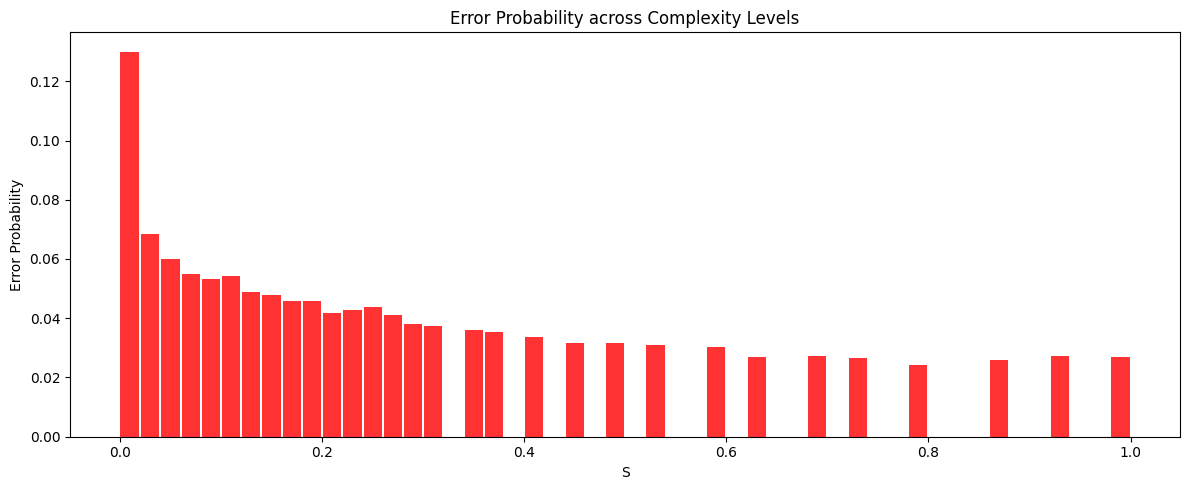

In [39]:
def plot_error_rate_equal_bins(df,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title=None):
    """
    按 value_col 等宽分箱，计算 error_col 的均值（错误率），
    打印每个区间的样本数 & 错误率，并画柱状图（柱子宽度相等）。
    """
    df_plot = df.copy()
    if exclude_zero:
        df_plot = df_plot[df_plot[value_col] > 0]

    bin_edges = np.linspace(0, 1, bins+1)
    df_plot['bin'] = pd.cut(df_plot[value_col], bins=bin_edges, include_lowest=True)
    stat_df = df_plot.groupby('bin').agg(
        count=(error_col, 'size'),
        error_rate=(error_col, 'mean')
    ).reset_index()

    lines = [f"{row['bin']}: n={row['count']}, err={row['error_rate']:.4f}" 
             for _, row in stat_df.iterrows()]
    print(f"\n=== {title or 'Equal Bin Error Rate'} ===")
    for i in range(0, len(lines), 2):
        if i + 1 < len(lines):
            print(f"{lines[i]:<55} | {lines[i+1]}")
        else:
            print(lines[i])

    bin_centers = [interval.mid for interval in stat_df['bin']]
    bin_width = bin_edges[1] - bin_edges[0]

    plt.figure(figsize=(12,5))
    plt.bar(bin_centers, stat_df['error_rate'], width=bin_width*0.9, alpha=0.8, color='red')
    plt.xlabel(value_col)
    plt.ylabel("Error Probability")
    plt.title(title or "Error Probability vs Complexity (equal width bins)")
    plt.tight_layout()
    plt.show()


plot_error_rate_equal_bins(df_moves,value_col='S',error_col='Is_Error',bins=50,exclude_zero=False,title="Error Probability across Complexity Levels")

# The results were contrary to intuition.

force moves check

In [41]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)

In [44]:
def ensure_list(x):
    if x is None:
        return []
    elif isinstance(x, list):
        return x
    elif isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    else:
        try:
            return list(x)
        except:
            return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, on=['Game_ID','Move_Idx'], how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)

In [45]:
df_moves.shape

(1959520, 12)

In [46]:
# S=0 且 Is_Forced=1 的行
forced_s_zero = df_moves[(df_moves['S'] == 0) & (df_moves['Is_Forced'] == 1)]
print(forced_s_zero.head())

print("S=0 且 Is_Forced=1 的步数:", len(forced_s_zero))
print("S=0的步数：", len(df_moves[(df_moves['S'] == 0)]))

      Game_ID  Move_Idx                 Player  Color    S     E1     E2    P  \
739    127224        37     Jakob Leon Pajeken  White  0.0 -213.0 -509.0  1.0   
1309   127231        41        Makhsum Bozorov  White -0.0   12.0 -533.0  1.0   
3171   127253        66  Abilmansur Abdilkhair  Black  0.0   26.0 -161.0  1.0   
3284   127254        88         Vahe Danielyan  Black  0.0  313.0   -5.0  1.0   
3286   127254        90         Vahe Danielyan  Black  0.0  384.0   98.0  1.0   

     Judgment_Raw  Is_Error  Is_Blunder  Is_Forced  
739             -         0           0          1  
1309            -         0           0          1  
3171      Blunder         1           1          1  
3284      Blunder         1           1          1  
3286            -         0           0          1  
S=0 且 Is_Forced=1 的步数: 2462
S=0的步数： 359391


S 值分布（强制走子数量）：
S
0.000    2462
0.001     262
0.002     124
0.003      68
0.004     106
         ... 
0.740     296
0.800     316
0.863     419
0.930     538
1.000    1042
Name: count, Length: 61, dtype: int64


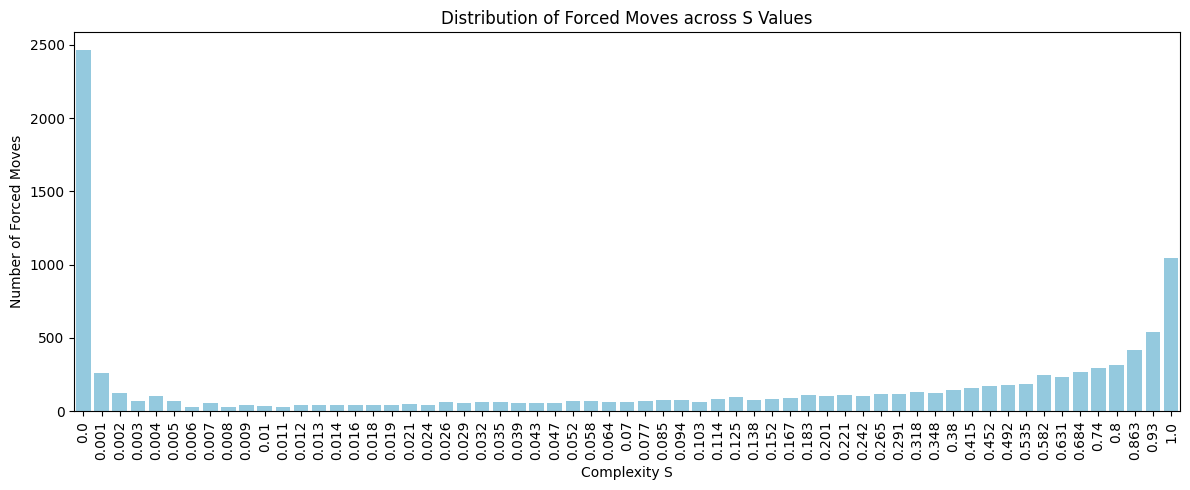

In [47]:
# 筛选出强制走子的步
forced_moves = df_moves[df_moves['Is_Forced'] == 1]

# 统计不同 S 值下的强制走子数量
S_distribution = forced_moves['S'].value_counts().sort_index()  # 按 S 值排序

print("S 值分布（强制走子数量）：")
print(S_distribution)

plt.figure(figsize=(12,5))
sns.barplot(x=S_distribution.index, y=S_distribution.values, color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Complexity S")
plt.ylabel("Number of Forced Moves")
plt.title("Distribution of Forced Moves across S Values")
plt.tight_layout()
plt.show()
